<div style="padding:38px;border-radius:18px;background:linear-gradient(135deg,#5a1025,#8c2946);color:white;text-align:center;font-family:Arial,sans-serif">
<div style="letter-spacing:2px;text-transform:uppercase">COMP 272 · Java Onboarding</div>
<h1 style="font-size:2.4em;margin:12px 0">Java for Python Programmers</h1>
<p style="font-size:1.2em;margin:0">A short tour of the philosophy, workflow, and details most likely to surprise you.</p></div>

## The mindset shift

Python optimizes for **speed of expression**. Java asks you to state more of the program’s structure up front so tools can check and navigate it.

| Python habit | Java emphasis |
|---|---|
| Types are mostly implicit | Types are part of variables and method contracts |
| Flexible module-level code | Executable code is organized in classes |
| Many mistakes appear while running | Many structural mistakes appear while compiling |
| Duck typing | Explicit interfaces and substitutable implementations |

For COMP 272, this explicitness helps us compare several implementations of the same data-structure contract.

## What kind of language is Java?

Java is a **statically typed, compiled, object-oriented** language.

| Characteristic | What it means |
|---|---|
| **Statically typed** | Every variable and expression has a type that is checked before the program runs. |
| **Compiled** | Java source code is translated into bytecode before it is executed by the Java Virtual Machine (JVM). |
| **Object-oriented** | Programs are organized mainly around classes and objects that combine data with behavior. |

These three characteristics shape how we write, check, and organize Java programs.

<div style="padding:24px 30px;border-radius:14px;background:#6b1730;color:white;font-family:Arial,sans-serif">
<div style="font-size:.82em;letter-spacing:2px;text-transform:uppercase">1</div><h1 style="margin:6px 0">Write → compile → run</h1><p style="margin:0;font-size:1.1em">Java separates source code, bytecode, and execution.</p></div>

## Smallest useful program

```java
public class HelloWorld {
    public static void main(String[] args) {
        System.out.println("Hello, COMP 272!");
    }
}
```

- The file must be named `HelloWorld.java` because the public class is `HelloWorld`.
- The JVM begins at `public static void main(String[] args)`.
- Braces define blocks; semicolons terminate statements.

## The workflow

<div style="display:flex;align-items:center;justify-content:center;gap:12px;text-align:center;font-family:Arial,sans-serif;margin:22px 0">
<div style="padding:16px;background:#eef4ff;border-radius:10px"><b>HelloWorld.java</b><br>source</div><div>— <code>javac</code> →</div>
<div style="padding:16px;background:#fff4e6;border-radius:10px"><b>HelloWorld.class</b><br>bytecode</div><div>— <code>java</code> →</div>
<div style="padding:16px;background:#eef8f1;border-radius:10px"><b>output</b><br>on the JVM</div></div>

In [ ]:
%%writefile HelloWorld.java
public class HelloWorld {
    public static void main(String[] args) {
        System.out.println("Hello, COMP 272!");
    }
}

In [ ]:
!javac HelloWorld.java
!java HelloWorld

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px;font-family:Arial,sans-serif"><b>Worth remembering · The notebook is not Java</b><br><code>%%writefile</code> and <code>!</code> are Python/Jupyter helpers. They create the Java file and invoke the same terminal commands you would use outside the notebook.</div>

## More than one source file

```bash
javac Student.java StudentDemo.java
java StudentDemo
```

Compile the related source files; run the class that contains `main`. For a small same-directory project, `javac *.java` is convenient.

As projects grow, build automation avoids repeatedly typing long commands. A **Makefile** can automate shell commands such as `javac`, while Java projects commonly use tools such as **Gradle** or **Maven** to manage compilation, testing, packaging, and external dependencies. We will return to build automation later, when the project is large enough for it to solve a real problem.

<div style="padding:24px 30px;border-radius:14px;background:#6b1730;color:white;font-family:Arial,sans-serif">
<div style="font-size:.82em;letter-spacing:2px;text-transform:uppercase">2</div><h1 style="margin:6px 0">Types and values</h1><p style="margin:0;font-size:1.1em">Java distinguishes primitive values from references.</p></div>

## Variables declare their type

```java
int count = 3;
double average = 87.5;
boolean ready = true;
char section = 'A';
String course = "COMP 272";
```

| Family | Examples | Variable contains |
|---|---|---|
| **Primitive** | `int`, `double`, `boolean`, `char` | The value itself |
| **Reference** | `String`, arrays, objects | A reference to an object—or `null` |

## The equality rule that causes real bugs

```java
int a = 100;
int b = 100;
System.out.println(a == b);          // true: primitive values

String x = new String("COMP 272");
String y = new String("COMP 272");
System.out.println(x == y);          // false: different objects
System.out.println(x.equals(y));     // true: same content
```

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px"><b>Rule of thumb</b><br>Use <code>==</code> for primitive values and reference identity. Use <code>.equals()</code> for object content. When either reference may be null, <code>Objects.equals(x, y)</code> is safer.</div>

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px;font-family:Arial,sans-serif"><b>Worth remembering · Strings are objects</b><br>Use double quotes for <code>String</code>, single quotes for one <code>char</code>, and <code>.equals()</code> for String content. String literals may make <code>==</code> appear to work because of interning—do not rely on it.</div>

<div style="padding:24px 30px;border-radius:14px;background:#6b1730;color:white;font-family:Arial,sans-serif">
<div style="font-size:.82em;letter-spacing:2px;text-transform:uppercase">3</div><h1 style="margin:6px 0">Familiar syntax, stricter contracts</h1><p style="margin:0;font-size:1.1em">The ideas are familiar; a few rules deserve attention.</p></div>

## Decisions and loops

```java
if (score >= 90) {
    System.out.println("A");
} else if (score >= 80) {
    System.out.println("B");
}

for (int i = 0; i < values.length; i++) { /* index needed */ }
for (int value : values) { /* visit each value */ }
while (condition) { /* repeat while true */ }
```

- Conditions must be actual `boolean` expressions—Java has no Python-style general truthiness.
- Logical operators are `&&`, `||`, and `!`.
- Prefer the enhanced `for` loop when you do not need an index.

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px;font-family:Arial,sans-serif"><b>Worth remembering · Assignment is an expression</b><br><code>if (ready = true)</code> compiles: it assigns <code>true</code>. Prefer <code>if (ready)</code>; do not confuse <code>=</code> with <code>==</code>.</div>

## Methods make the contract visible

```java
public static int square(int n) {
    return n * n;
}
```

The signature states the return type, method name, and parameter types. `void` means no returned value. Java also supports **overloading**: the same method name may have different parameter lists.

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px;font-family:Arial,sans-serif"><b>Worth remembering · Java is always pass-by-value</b><br>For an object argument, Java copies the reference value. A method can mutate the referenced object, but it cannot replace the caller’s variable with a different object.</div>

<div style="padding:24px 30px;border-radius:14px;background:#6b1730;color:white;font-family:Arial,sans-serif">
<div style="font-size:.82em;letter-spacing:2px;text-transform:uppercase">4</div><h1 style="margin:6px 0">Classes organize state and behavior</h1><p style="margin:0;font-size:1.1em">Encapsulation is not ceremony; it protects invariants.</p></div>

## A compact class

```java
public class Student {
    private String name;
    private double gpa;

    public Student(String name, double gpa) {
        this.name = name;
        this.gpa = gpa;
    }

    public String getName() { return name; }
    public double getGpa() { return gpa; }

    @Override
    public String toString() {
        return name + " (" + gpa + ")";
    }
}
```

- **Fields** store each object’s state.
- A **constructor** establishes the initial state.
- `private` hides representation; public methods define permitted access.
- `this.gpa` is the field of the current object; `gpa` is the parameter.
- `@Override` asks the compiler to verify that `toString()` really overrides an inherited method.

## Encapsulation in Java

Encapsulation exists in both Python and Java, but Java enforces it more directly. Python mostly communicates privacy by convention—such as `_name`—and name mangling with `__name` only discourages accidental access. Java places access rules in the language itself. A field declared `private` cannot be accessed directly from another class; outside code must use the operations the class deliberately exposes. This makes it easier for a class to protect its **invariants**. For a data structure, for example, callers should be able to add or remove elements without directly changing internal nodes, links, or the stored size.

Java provides four progressively broader access levels:

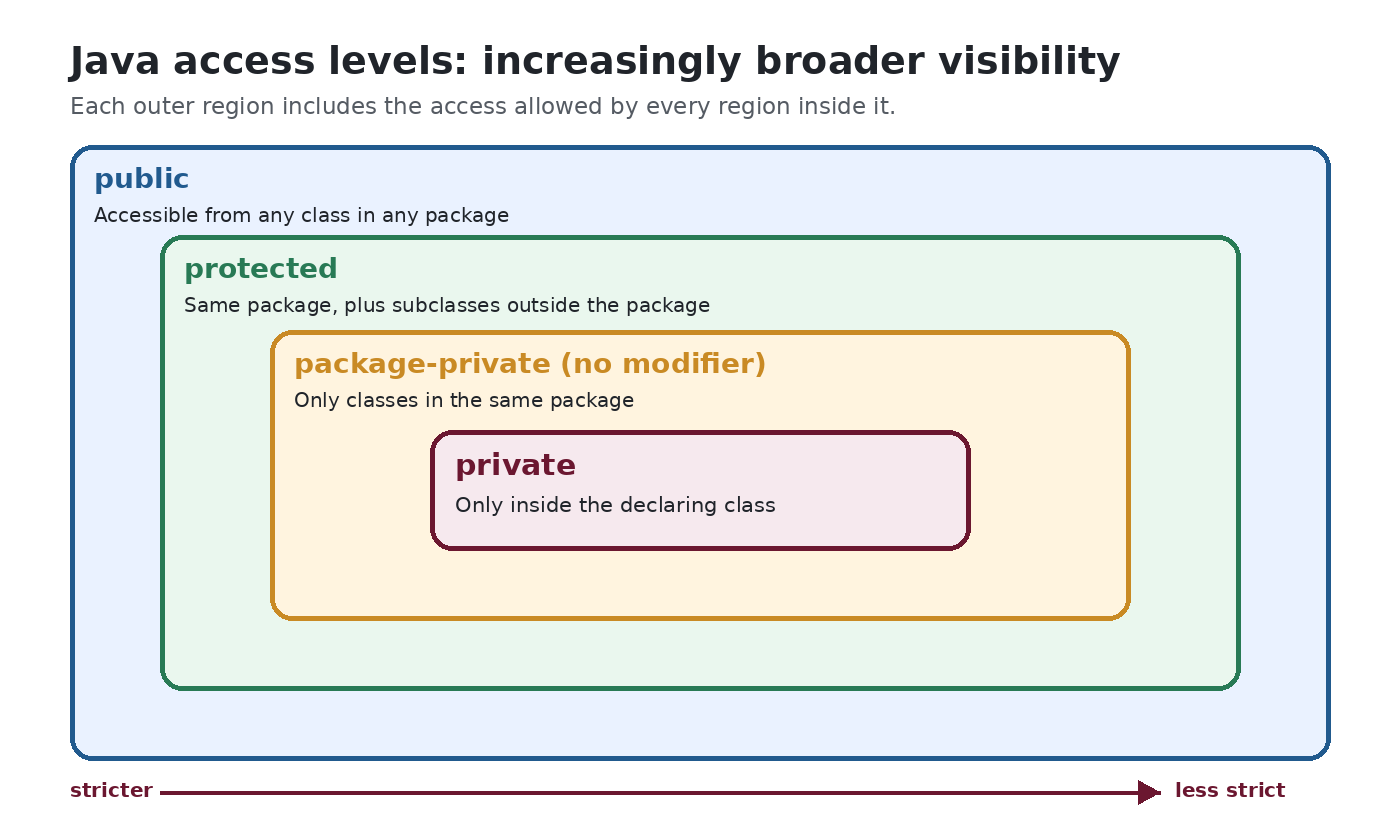

## What is a package?

A **package** is Java’s way of grouping related classes and interfaces under a shared name, similar in purpose to a Python package or module namespace. It organizes a project, prevents naming conflicts, and contributes to access control.

```java
package edu.luc.comp272.structures;
```

This declaration means that the class belongs to `edu.luc.comp272.structures`; its directory structure normally mirrors that name. Package-private members are accessible only to other classes in the same package, while `protected` additionally permits access from subclasses outside the package.

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px;font-family:Arial,sans-serif"><b>Worth remembering · Instance versus static</b><br>Instance members belong to an object and are accessed through a reference. <code>static</code> members belong to the class itself. <code>main</code> is static because the JVM calls it before creating an object.</div>

## Arrays: deliberately limited

```java
int[] scores = {88, 92, 79};
System.out.println(scores.length);  // field, not length()
System.out.println(scores[0]);
```

Arrays have a fixed length and are reference types. Invalid indices throw `ArrayIndexOutOfBoundsException`. Unlike a Python list, an array does not grow; resizable behavior comes from collection classes such as `ArrayList`.

<div style="padding:24px 30px;border-radius:14px;background:#6b1730;color:white;font-family:Arial,sans-serif">
<div style="font-size:.82em;letter-spacing:2px;text-transform:uppercase">5</div><h1 style="margin:6px 0">null, exceptions, and debugging</h1><p style="margin:0;font-size:1.1em">Failures carry useful information.</p></div>

## A reference may point to nothing

```java
Student student = null;
student.getName();       // NullPointerException at runtime
```

`null` is available only to reference types. Calling a method or accessing a field through `null` throws `NullPointerException`. A program may compile successfully and still fail at runtime.

## Read the stack trace from the top

1. **Exception type** — what kind of failure occurred?
2. **Message** — what detail did the JVM provide?
3. **First line in your code** — where did the failure reach your program?

Common early exceptions: `NullPointerException`, `ArrayIndexOutOfBoundsException`, `ArithmeticException`, and `NumberFormatException`.

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#fff9ed;border-radius:8px;font-family:Arial,sans-serif"><b>Worth remembering · Compiler success is not correctness</b><br>Compilation proves that the code satisfies Java’s language and type rules. Tests and careful reasoning are still required to detect logical errors.</div>

<div style="padding:24px 30px;border-radius:14px;background:#6b1730;color:white;font-family:Arial,sans-serif">
<div style="font-size:.82em;letter-spacing:2px;text-transform:uppercase">6</div><h1 style="margin:6px 0">Conventions that help you read Java</h1><p style="margin:0;font-size:1.1em">The ecosystem expects consistent names and structure.</p></div>

| Element | Convention | Example |
|---|---|---|
| Class/interface | `PascalCase` | `LinkedList` |
| Variable/method | `camelCase` | `courseCode`, `getName()` |
| Constant | `UPPER_SNAKE_CASE` | `MAX_SIZE` |
| Package | lowercase | `edu.luc.comp272` |

One public top-level class per matching filename is the usual structure. Packages organize code; imports make external class names available.

## What to retain

1. Java makes program structure and contracts explicit.
2. `javac` compiles source into bytecode; `java` runs a class on the JVM.
3. Primitive values and object references behave differently—especially with equality.
4. Classes protect invariants through private state and controlled methods.
5. Compilation catches many errors, but runtime and logical errors remain.

### Quick understanding check

1. Why can two different `String` objects satisfy `.equals()` but not `==`?
2. What does `javac` produce, and which class should you pass to `java`?
3. Why must a Java `if` condition be different from Python’s `if value:`?
4. What is the difference between an instance member and a `static` member?
5. Why are private fields useful when implementing a data structure?
6. What information should you look for first in a stack trace?

**Next:** arrays and the distinction between an abstract data type and its implementations.